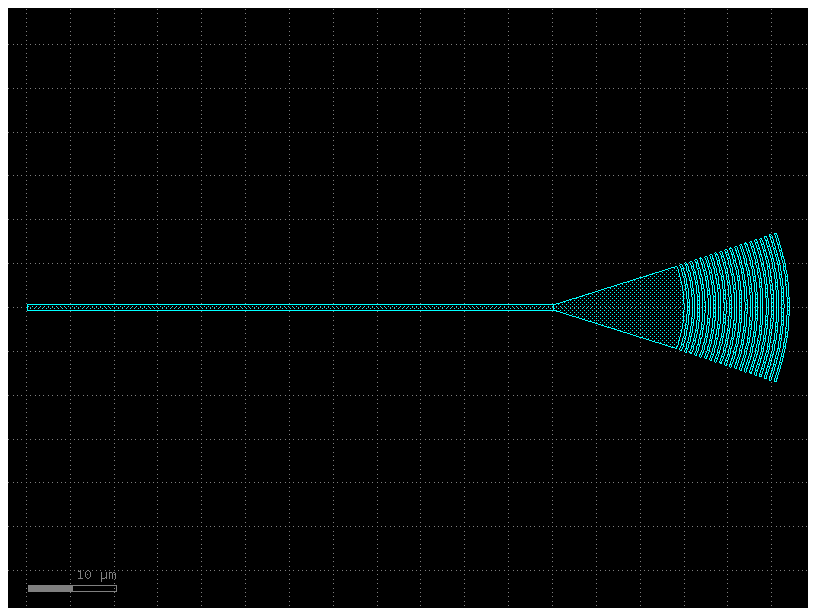

In [1]:
import gdsfactory as gf

from AL_Taper import AL_Taper
from AL_GratingCoupler import AL_GratingCoupler
import IO_AQH_1
gf.gpdk.PDK.activate()
from AQH_CB_Device import AQH_CB_Device
from AFQH_Device import AFQH_Device
from OneD_Device import OneD_Device
from AQH_Device_Rot import AQH_Device_Rot
from IO_2D_1 import IO_2D_1
from IO_AQH_1 import IO_AQH_1
from IO_AQH_2 import IO_AQH_2
from IO2 import IO2
from IO7_Pulley import IO7_Pulley
from SurpentineLossWg import SurpentineLossWg
from DirCoupler_Device import DirCoupler_Device
 
from ADF_RIO import ADF_RIO

# c = OneD_Device(TotLengthX=800,FAGap=127,CouplerON=0,OutputIO=False)

# c = AQH_Device_Rot(CouplerON=2)
# c= SurpentineLossWg(TotLengthX=500,MidLengthX=500,NCurves=0,InLengthX=500,OutIOOn=False,TaperOn=0)

# c = AFQH_Device(CouplerON=3,FAGap=2*127)

# c = AQH_Device_Rot()

# c = ADF_RIO(InIO         = 7,  
#     TaperOn     = False, 
#     OutputIO    = False,
#     ThetaC       = 10,
#     BendRadius=150,
#     BendRadiusIO=25,
#     LengthRingY=0,
#     LengthRingX=0,
# )

c = AL_GratingCoupler()

# c = IO_2D_1(InLengthY=300)

c.show()
c.plot()
# c.write_gds("2D_Device_test.gds")

WindowsPath('AL_Taper.gds')

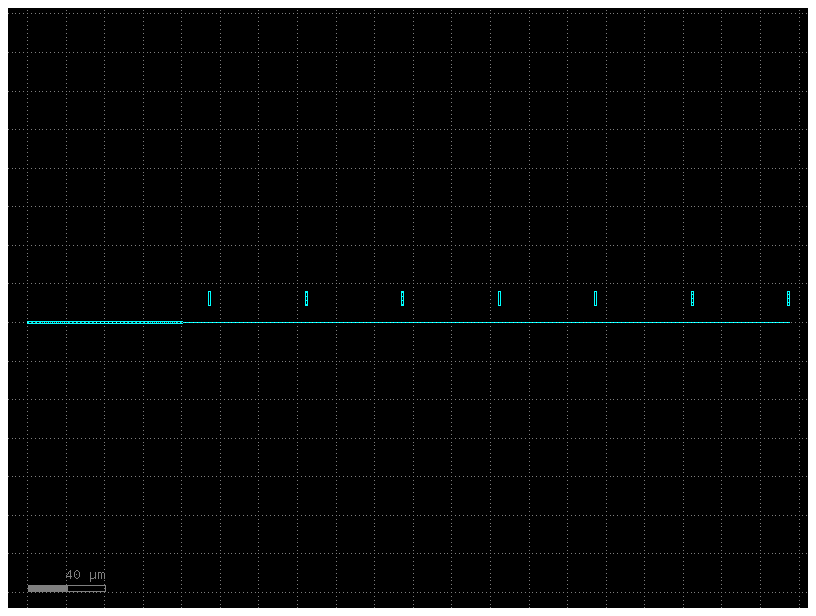

In [2]:
import gdsfactory as gf
from AL_Taper import AL_Taper

c = gf.Component()

c << AL_Taper(MarkerOn=True)
# c << AL_GratingCoupler(WgWidthIO=1.0,layer=(10,0))

c.show()
c.plot()
c.write_gds("AL_Taper.gds")

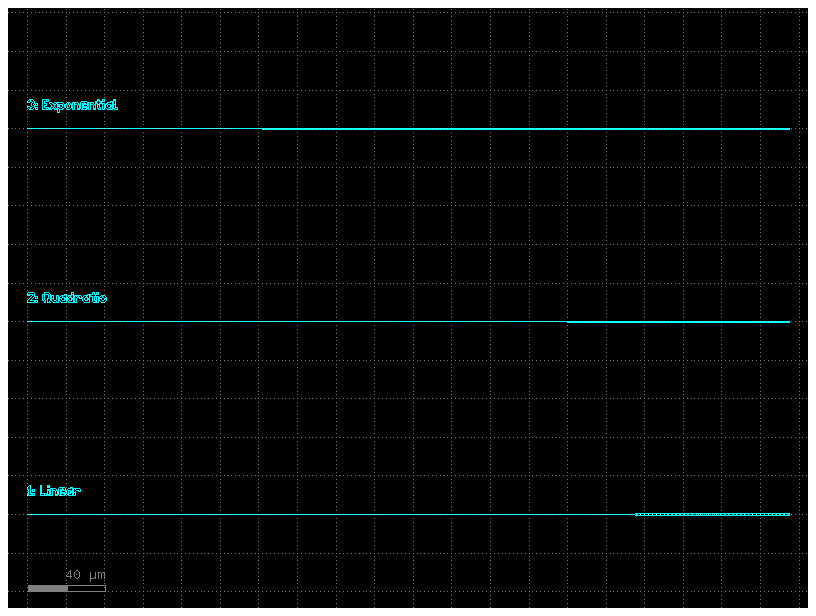

In [3]:
import gdsfactory as gf

@gf.cell
def Test_AL_Tapers():
    C = gf.Component()

    WidthEnd   = 0.2
    WidthStart = 0.6
    Length     = 395
    Layer      = (2, 0)

    YStep = 100

    taper_names = {
        1: "Linear",
        2: "Quadratic",
        3: "Exponential",
    }

    for i, TaperType in enumerate([1, 2, 3]):

        T = C << AL_Taper(
            WidthEnd=WidthEnd,
            WidthStart=WidthStart,
            Length=Length,
            Layer=Layer,
            TaperType=TaperType,
            NPoints=81,
            MarkerOn=False,
        )

        T.move((0, i * YStep))

        txt = C << gf.components.text(
            text=f"{TaperType}: {taper_names[TaperType]}",
            size=5,
            layer=Layer,
        )
        txt.move((0, i* YStep +10))

    return C


C = Test_AL_Tapers()
gds_path = "Test_AL_Tapers.gds"
C.write_gds(gds_path)
C.show()
C.plot()

WindowsPath('AL_Taper_type1_Straight.gds')

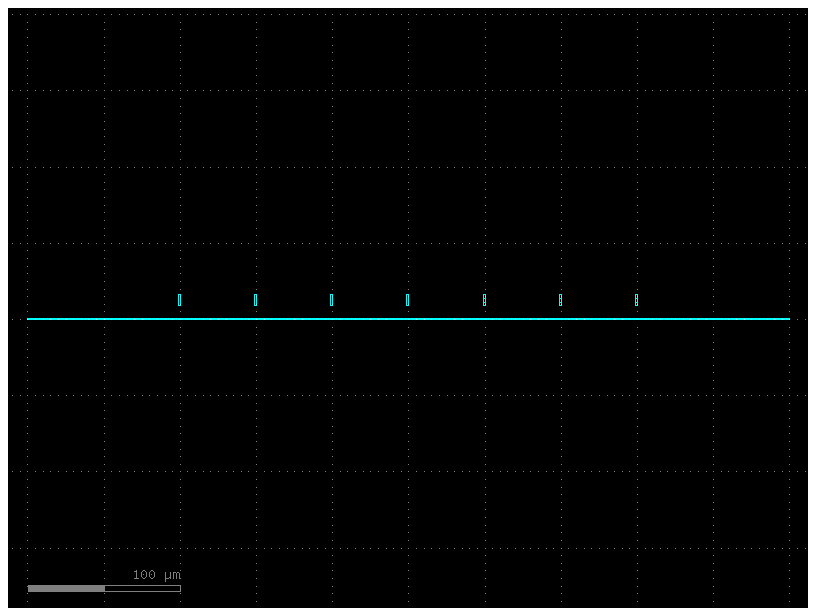

In [11]:
from AL_Taper import AL_Taper
from Straight import Straight

c = gf.Component()

T1 = c << AL_Taper(WidthEnd=0.2, WidthStart=0.7, Length=400, TaperType=1, NPoints=1000, MarkerOn=True,Layer =(2,0))
S1 = c << Straight(Length=100, Width=0.7,Layer=(2,0))

T1.connect("o2",S1.ports["o1"])
c.add_port("o1", port=T1.ports["o1"])
c.add_port("o2", port=S1.ports["o2"])

c.show()
c.plot()
c.write_gds("AL_Taper_type1_Straight.gds")